<a href="https://colab.research.google.com/github/amine-banani/Deep-Learning-Framework-for-Multi-Organ-Semantic-Segmentation/blob/main/atelier_ia_cadarache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/amine-banani/atelier-ia-images.git
%cd atelier-ia-images

Cloning into 'atelier-ia-images'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 4.13 MiB | 16.59 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/kaggle/working/atelier-ia-images


In [ ]:
IMAGE_PATH = "maria-sime-349-eXDixFE-unsplash.jpg"

# Comment une IA voit-elle une image ?

Prenez quelques secondes.

**Qu’est-ce que vous voyez ?**

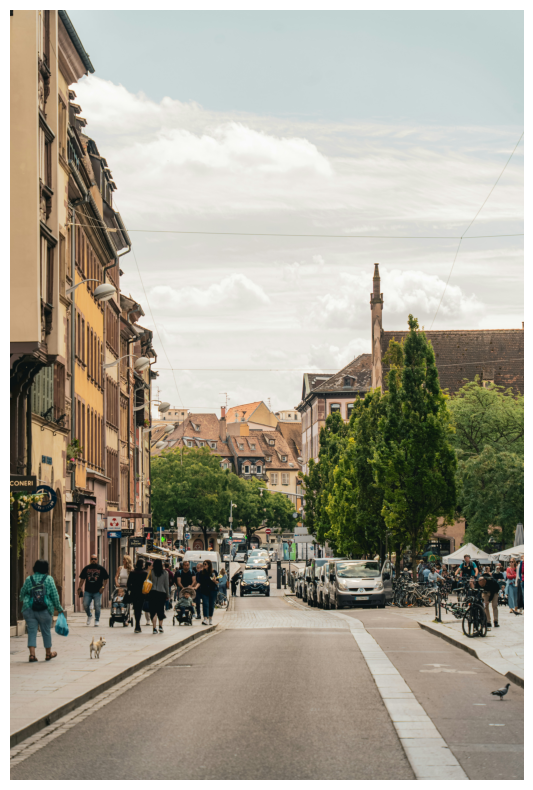

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(16, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

## Et au-delà des objets ?

**Qu’est-ce que vous comprenez de la scène ?**

---

Nous venons de reconnaître des objets, des relations et un contexte.

Mais l’ordinateur, lui, ne reçoit rien de tout cela directement.

**Alors, qu’est-ce qu’il reçoit réellement ?**

In [ ]:
import numpy as np

arr = np.array(image)

print("Taille de l'image :", arr.shape)
print("Type des valeurs :", arr.dtype)
print("Exemple d'un pixel RGB :", arr[200, 300])

Taille de l'image : (7008, 4672, 3)
Type des valeurs : uint8
Exemple d'un pixel RGB : [172 141 113]


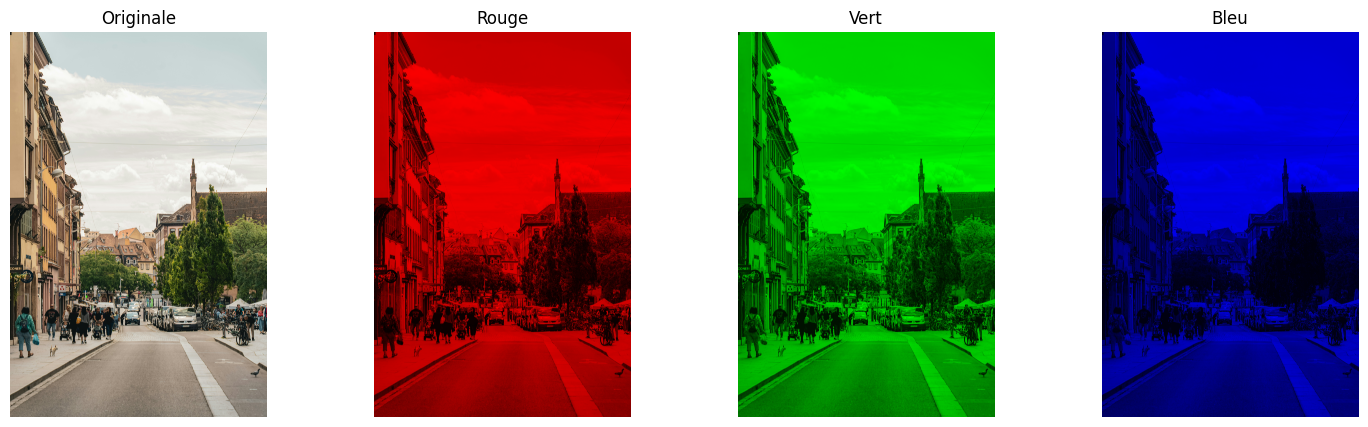

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(arr)
axes[0].set_title("Originale")

colors = [
    (0, "Rouge"),
    (1, "Vert"),
    (2, "Bleu")
]

for j, (i, name) in enumerate(colors, start=1):
    channel_img = np.zeros_like(arr)
    channel_img[:, :, i] = arr[:, :, i]

    axes[j].imshow(channel_img)
    axes[j].set_title(name)

for ax in axes:
    ax.axis("off")

plt.show()

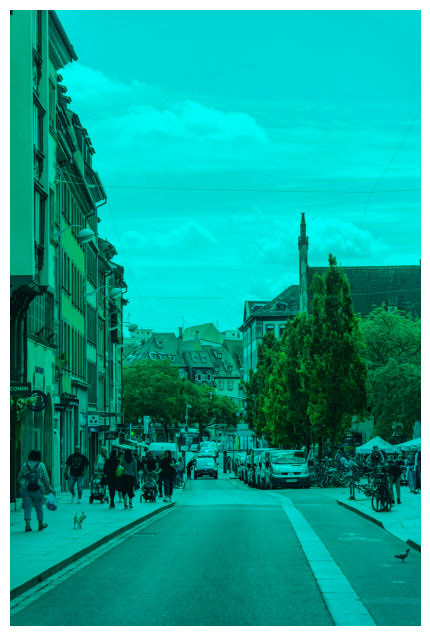

In [ ]:
def remove_channel(image_array, channel):
    out = image_array.copy()
    idx = {"red": 0, "green": 1, "blue": 2}[channel]
    out[:, :, idx] = 0
    return out

modified = remove_channel(arr, "red")

plt.figure(figsize=(14, 8))
plt.imshow(modified)
plt.axis("off")
plt.show()

# 2. Classification

Jusqu’ici, nous avons regardé l’image comme une donnée numérique.

Maintenant, donnons-la à un modèle déjà entraîné pour reconnaître des catégories d’images.

**Question : si on oblige le modèle à résumer toute cette scène avec une seule étiquette, que va-t-il répondre ?**

In [ ]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device)
model.eval()

preprocess = weights.transforms()
labels = weights.meta["categories"]

In [ ]:
import matplotlib.pyplot as plt

def classify(image, topk=5):
    x = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    values, indices = probs.topk(topk)

    results = [
        (labels[idx], float(prob))
        for prob, idx in zip(values, indices)
    ]

    names = [r[0] for r in results][::-1]
    scores = [r[1] * 100 for r in results][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(names, scores)
    plt.xlabel("Confiance (%)")
    plt.title("Top 5 prédictions")
    plt.show()

    return results

## Prédiction du modèle

Le modèle utilisé ici a été entraîné sur ImageNet, avec 1000 catégories possibles.

Il ne cherche donc pas à décrire toute la scène : il cherche la catégorie qui ressemble le plus à ce qu’il a appris.

In [ ]:
results = classify(image)
results

## À retenir

Le modèle ne répond pas à :

**« Qu’est-ce qu’il y a dans cette scène ? »**

Il répond plutôt à :

**« Parmi les catégories que je connais, laquelle correspond le mieux à cette image ? »**

Même image, mais une tâche très précise.